In [18]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

In [19]:
from pathlib import Path

path = Path(
    "src/data/foliage/WORLDCOVER/ESA_WORLDCOVER_10M_2021_V200/"
    "MAP/ESA_WorldCover_10m_2021_v200_N30W117_Map/"
    "ESA_WorldCover_10m_2021_v200_N30W117_Map.tif"
).resolve()

print(path)

C:\Users\David\Projects\scenic-route\processing\src\data\foliage\WORLDCOVER\ESA_WORLDCOVER_10M_2021_V200\MAP\ESA_WorldCover_10m_2021_v200_N30W117_Map\ESA_WorldCover_10m_2021_v200_N30W117_Map.tif


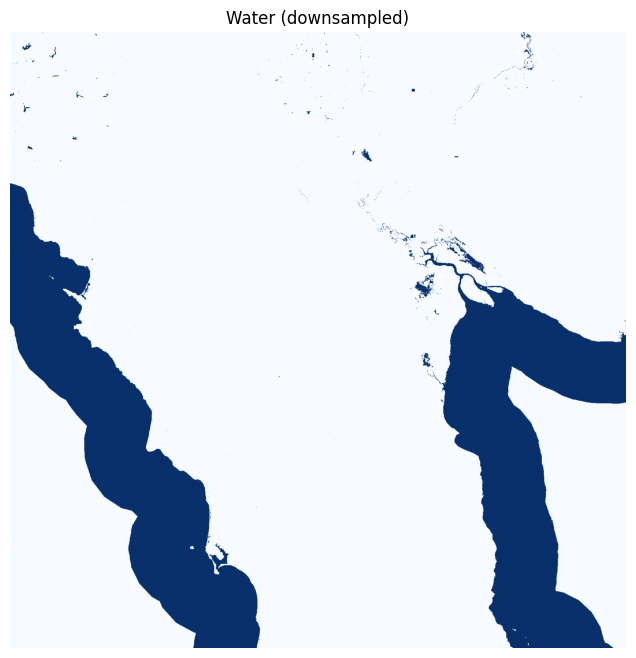

In [20]:
with rasterio.open(path) as src:
    scale = 20  # increase if you still hit memory limits
    data = src.read(
        1,
        out_shape=(
            src.height // scale,
            src.width // scale
        ),
        resampling=Resampling.nearest
    )

# Extract water (ESA WorldCover: 80 = water)
water = data == 80

plt.figure(figsize=(8, 8))
plt.imshow(water, cmap="Blues")
plt.title("Water (downsampled)")
plt.axis("off")
plt.show()
